In [1]:
import yfinance as yf
import pandas as pd, numpy as np
import xgboost as xgb, lightgbm as lgb
import ta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_sample_weight
warnings.filterwarnings("ignore")

In [2]:
def evaluate_model(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
    }

In [3]:
def train_base_model(X_train, y_train, X_valid=None, y_valid=None, model_name="LOG"):
    sc = None
    train_weights = compute_sample_weight('balanced', y_train)
    val_weights = compute_sample_weight('balanced', y_valid)
    if model_name == "LOG":
        sc = StandardScaler()
        model = LogisticRegression(class_weight="balanced", max_iter=1000)
        X_train_scaled = sc.fit_transform(X_train)
        model.fit(X_train_scaled, y_train)
    elif model_name == "XGB":
        model = xgb.XGBClassifier(n_estimators=10000, early_stopping_rounds=50, objective="binary:logistic")
        model.fit(X_train,y_train,eval_set=[(X_valid, y_valid)],verbose=False,sample_weight=train_weights, sample_weight_eval_set=[val_weights])
    elif model_name == 'LGB':
        model = lgb.LGBMClassifier(n_estimators=10000, random_state=1, objective="binary", class_weight="balanced")
        model.fit(X_train,y_train,eval_set=[(X_valid, y_valid)], callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
    return model, sc

In [4]:
TICKER = 'BTC-USD'
PERIOD = "3y"
Ticker = yf.Ticker(ticker=f'{TICKER}')
df = Ticker.history(PERIOD)
start = df.index.min()
end = df.index.max()
sample_size = len(df)
print(f'✅ Downloaded {TICKER} data from {start} to {end}, total bars: {sample_size}')

df["SMA9"] = df["Close"].rolling(window=9).mean()
df["SMA25"] = df["Close"].rolling(window=25).mean()
df["Log_Return_1d"] = df["Close"].pct_change()
df["Volatility9"] = df["Log_Return_1d"].rolling(window=9).std()
df["Close_SMA9_ratio"] = (df["Close"] - df["SMA9"]) / df["SMA9"]
df["Close_SMA25_ratio"] = (df["Close"] - df["SMA25"]) / df["SMA25"]

df["Close_High"] = df["Close"] / df["High"]
df["Close_Low"] = df["Close"] / df["Low"]

rsi = ta.momentum.RSIIndicator(close=df["Close"])
df["RSI"] = rsi.rsi()
df["Overbought"] = (df["RSI"] > 70).astype(int)
df["Oversold"] = (df["RSI"] < 30).astype(int)

macd = ta.trend.MACD(close=df["Close"])
df["MACD"] = macd.macd()
df["Signal_Line"] = macd.macd_signal()
df["MACD_Diff"] = ta.trend.macd_diff(df["Close"])
df["MACD_bullish"] = (df["MACD"] > 0).astype(int)
df["MACD_bearish"] = (df["MACD"] < 0).astype(int)
df["Bull_Crossover"] = (df["MACD"] > df["Signal_Line"]).astype(int)
df["Bearish_Crossover"] = (df["MACD"] > df["Signal_Line"]).astype(int)


# df["Price_Change_5d_later"] = df["Price_Change_5d"].shift(-5)
# df.loc[df["Price_Change_5d_later"] >= 0.04, "Target"] = 0  # Buy
# df.loc[df["Price_Change_5d_later"] <= -0.04, "Target"] = 2  # Sell
# df.loc[df["Target"].isna(), "Target"] = 1  # Hold
df["Target"] = (df["Close"].shift(-5) > df["Close"]).astype(int)
df.dropna(inplace=True)
df.drop(columns=["Dividends", "Stock Splits"], inplace=True)
print(f"✅ Features Engineered...")
print(f"✅ Data cleaned...")

✅ Downloaded BTC-USD data from 2023-04-04 00:00:00+00:00 to 2026-04-04 00:00:00+00:00, total bars: 1097
✅ Features Engineered...
✅ Data cleaned...


In [5]:
target_labels = {0:'Down', 1:'Up'}
df['Target'].value_counts(normalize=True).sort_index()

Target
0    0.477444
1    0.522556
Name: proportion, dtype: float64

In [6]:
features = ['Volume', 'SMA9', 'Volatility9', 'Close_High',  'Overbought', 'Oversold',  'MACD_bullish', 'Bull_Crossover', 'Bearish_Crossover'
            # 'RSI',
            # 'MACD_Diff',
            # 'Close_Low',
            ]

In [7]:
train_end_date = "2025-06-30"

train_data = df[:train_end_date]
test_data = df[train_end_date:]
X_train, y_train = train_data[features], train_data["Target"]
X_test, y_test = test_data[features], test_data["Target"]
train_size = len(X_train)
test_size = len(X_test)
print(f"✅ Data split done. Train: {train_size}, Test: {test_size}")

✅ Data split done. Train: 786, Test: 279


In [8]:
splits = 5
tscv = TimeSeriesSplit(n_splits=splits)
metrics = []
for train_idx, valid_idx in tscv.split(X_train, y_train):
    x_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    x_va, y_va = X_train.iloc[valid_idx], y_train.iloc[valid_idx]

    xgb_cl, _ = train_base_model(x_tr, y_tr, x_va, y_va, model_name="XGB")
    y_pred = xgb_cl.predict(x_va)
    results = evaluate_model(y_va, y_pred, "XGB")
    metrics.append(results)
print("Cross Validation Results:\n", pd.DataFrame(metrics).to_string(max_colwidth=50))

Cross Validation Results:
   model  precision    recall        f1      confusion_matrix
0   XGB   0.596491  0.447368  0.511278  [[32, 23], [42, 34]]
1   XGB   1.000000  0.100000  0.181818    [[51, 0], [72, 8]]
2   XGB   0.270270  0.149254  0.192308  [[37, 27], [57, 10]]
3   XGB   0.595238  0.337838  0.431034  [[40, 17], [49, 25]]
4   XGB   0.653846  0.215190  0.323810   [[43, 9], [62, 17]]


In [9]:
# Fit the final model on full training Data
# Predict Validation Data
# Predict Training Data

train_sample_size = int(X_train.shape[0] * 0.8)
x_tr, y_tr = X_train.iloc[:train_sample_size], y_train.iloc[:train_sample_size]
x_va, y_va = X_train.iloc[train_sample_size:], y_train.iloc[train_sample_size:]
xgb_cl, _ = train_base_model(x_tr, y_tr, x_va, y_va, model_name="XGB")
y_pred = xgb_cl.predict(x_va)
results = evaluate_model(y_va, y_pred, "XGB")
print("Validation data Results:\n", pd.DataFrame([results]).to_string(max_colwidth=50))

y_train_pred = xgb_cl.predict(X_train)
full_results = evaluate_model(y_train, y_train_pred, "XGB")
print("\nTrain Data Results:\n", pd.DataFrame([full_results]).to_string(max_colwidth=50))

Validation data Results:
   model  precision    recall        f1      confusion_matrix
0   XGB      0.625  0.224719  0.330579  [[57, 12], [69, 20]]

Train Data Results:
   model  precision    recall        f1         confusion_matrix
0   XGB   0.745509  0.576389  0.650131  [[269, 85], [183, 249]]


In [10]:
# Predict Testing Data

y_test_pred = xgb_cl.predict(X_test)
test_results = evaluate_model(y_test, y_test_pred, "XGB")
print("Test Results:\n", pd.DataFrame([test_results]).to_string(max_colwidth=50))

Test Results:
   model  precision  recall       f1        confusion_matrix
0   XGB   0.378378   0.112  0.17284  [[131, 23], [111, 14]]


In [15]:
print('Test Prediction Class proportions:')
print(pd.Series(y_test_pred).value_counts(normalize=True).sort_index())

Test Prediction Class proportions:
0    0.867384
1    0.132616
Name: proportion, dtype: float64


In [16]:
df_test = test_data.copy()
df_test["pred"] = y_test_pred

# Correct mapping
signal_map = {0: -1, 1: 1}
df_test["signal"] = df_test["pred"].map(signal_map)

# Returns
df_test["ret_5d"] = df_test["Close"].pct_change(5)

# Apply with lag
df_test["strategy_ret"] = df_test["signal"].shift(1) * df_test["ret_5d"]

# Performance
cum_return = (1 + df_test["strategy_ret"]).cumprod()
sharpe = df_test["strategy_ret"].mean() / df_test["strategy_ret"].std() * np.sqrt(252)

print("Sharpe:", sharpe)

Sharpe: -0.726881968565833


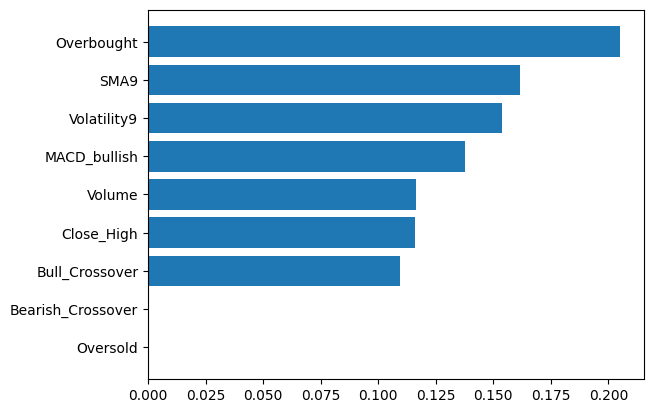

In [13]:
feature_importances = pd.DataFrame(
    {
        'Feature': X_train.columns,
        'Importance': xgb_cl.feature_importances_
    }
).sort_values(by='Importance', ascending=True)
plt.barh(feature_importances['Feature'], feature_importances['Importance'])
plt.show()

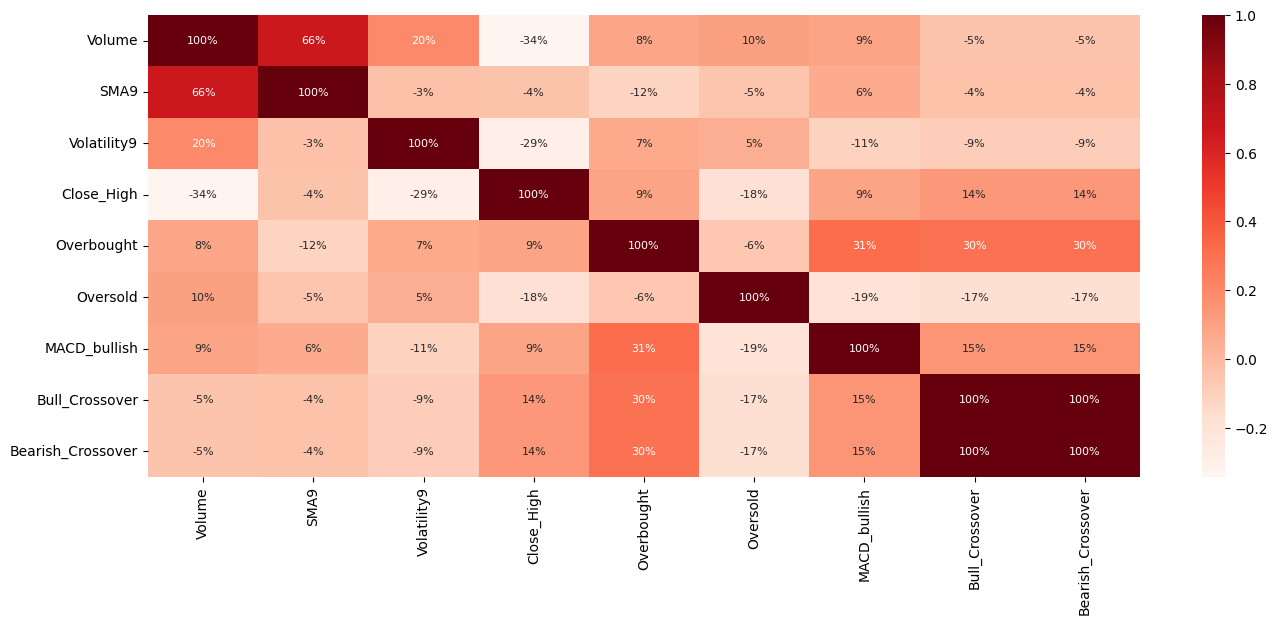

In [14]:
plt.figure(figsize=(16, 6))
sns.heatmap(
    df[features].corr(), cmap="Reds", fmt="0.0%", annot=True, annot_kws={"size": 8}
)
plt.show()